# Lecture 1 (Extended Materials), Notebook 03: Multi-Component Loss Balancing (ReLoBRaLo)

**Course:** CEMRACS 2026 Summer School — Modeling and AI for Environmental Transition · Lecture 1 (July 14, 2026, CIRM, Marseille)  
**Script reference:** §4.8 (multi-component losses: the scale problem; inverse-loss weighting; ReLoBRaLo Components 1–3; sensitivity to the temperature $T$)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC Lausanne · Grantham Research Institute, LSE)  

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


This notebook accompanies **Session 2 — Multi-Component Loss Balancing** (slides: `02_02_loss_normalization.pdf`).

**Goals:**
1. Understand why multi-component losses at different scales cause problems.
2. Train a multi-output NN with equal weights and observe failure.
3. Implement inverse-loss weighting and see partial improvement.
4. Implement a deterministic classroom version of ReLoBRaLo (Bischof & Kraus, 2025) and achieve balanced learning.
5. Study sensitivity to the temperature parameter $T$.

---

**Outline**

| Section | Topic |
|:--------|:------|
| 1 | Target functions at different scales |
| 2 | Multi-output network |
| 3 | Baseline: equal weighting |
| 4 | Inverse-loss weighting |
| 5 | ReLoBRaLo |
| 6 | Comparison |
| 7 | Sensitivity to $T$ |
| 8 | Discussion |

In [1]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Consistent plot style
rcParams.update({
    "figure.dpi":       120,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "font.family":      "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

# Colour palette
C_A     = "#2a9d8f"   # teal (small scale)
C_B     = "#e76f51"   # orange-red (medium scale)
C_C     = "#264653"   # dark blue (large scale)
C_EQUAL = "#6c757d"   # grey
C_INV   = "#e9c46a"   # gold
C_RELO  = "#457b9d"   # steel blue

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

2026-04-24 12:34:55.990394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777026896.028381  308954 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777026896.039160  308954 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-24 12:34:56.075776: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0


---
## 1. The Multi-Component Loss Problem

We approximate **three functions simultaneously** with a shared-trunk NN.
The functions live at vastly different scales:

| Function | Formula | Scale |
|:---------|:--------|:------|
| $f_A(\mathbf{x})$ | $\text{genz\_gaussian}(\mathbf{x})$ | $[0, 1]$ |
| $f_B(\mathbf{x})$ | $100 \times \text{genz\_oscillatory}(\mathbf{x})$ | $[-100, 100]$ |
| $f_C(\mathbf{x})$ | $10{,}000 \times \text{genz\_continuous}(\mathbf{x})$ | $[0, 10{,}000]$ |

The composite loss is:
$$\mathcal{L} = w_A \cdot \text{MSE}_A + w_B \cdot \text{MSE}_B + w_C \cdot \text{MSE}_C$$

With equal weights ($w_A = w_B = w_C = 1$), $\text{MSE}_C \approx 2\times 10^7$
dominates while $\text{MSE}_A \approx 0.4$ is essentially ignored.

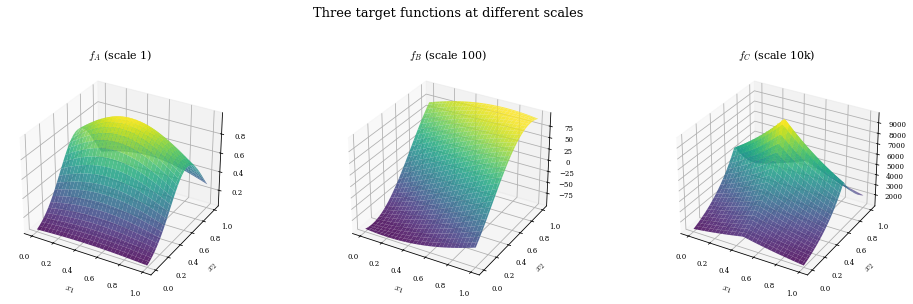

$f_A$ (scale 1): range [0.05, 1.00]
$f_B$ (scale 100): range [-100.00, 100.00]
$f_C$ (scale 10k): range [1062.41, 9762.24]


In [2]:
# ----------------------------------------------------------------
# Define the three Genz target functions (from Notebook 06)
# ----------------------------------------------------------------

def genz_gaussian(X, c, w):
    """f4: exp(-sum_i c_i^2 * (x_i - w_i)^2)"""
    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))

def genz_oscillatory(X, c, w):
    """f1: cos(2*pi*w[0] + sum_i c_i * x_i)"""
    return np.cos(2.0 * np.pi * w[0] + X @ c)

def genz_continuous(X, c, w):
    """f5: exp(-sum_i c_i * |x_i - w_i|)"""
    return np.exp(-np.sum(c * np.abs(X - w), axis=1))

# Fixed parameters
d = 2
rng = np.random.RandomState(7)
c_param = rng.uniform(1.0, 3.0, size=d)
w_param = rng.uniform(0.2, 0.8, size=d)

# Multi-scale target functions
def f_A(X): return genz_gaussian(X, c_param, w_param)          # scale ~ 1
def f_B(X): return 100.0 * genz_oscillatory(X, c_param, w_param)  # scale ~ 100
def f_C(X): return 10000.0 * genz_continuous(X, c_param, w_param)  # scale ~ 10000

TARGETS = {"$f_A$ (scale 1)": f_A, "$f_B$ (scale 100)": f_B, "$f_C$ (scale 10k)": f_C}
TARGET_COLORS = [C_A, C_B, C_C]

# Visualise
grid_n = 60
t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(t, t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(14, 4),
                         subplot_kw={"projection": "3d"})
for ax, (name, fn), col in zip(axes, TARGETS.items(), TARGET_COLORS):
    Z = fn(X_grid).reshape(grid_n, grid_n)
    ax.plot_surface(X1, X2, Z, cmap="viridis", alpha=0.85,
                    edgecolor="none", rcount=50, ccount=50)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=9)
    ax.set_ylabel("$x_2$", fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("Three target functions at different scales", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

for name, fn in TARGETS.items():
    vals = fn(X_grid)
    print(f"{name}: range [{vals.min():.2f}, {vals.max():.2f}]")

In [3]:
# ----------------------------------------------------------------
# Generate training and test data
# ----------------------------------------------------------------
n_train = 1000
n_test = 2000

X_train = np.random.uniform(0, 1, size=(n_train, d)).astype(np.float32)
X_test = np.random.uniform(0, 1, size=(n_test, d)).astype(np.float32)

# Targets as arrays: shape (n, 3)
y_train_A = f_A(X_train).astype(np.float32)
y_train_B = f_B(X_train).astype(np.float32)
y_train_C = f_C(X_train).astype(np.float32)

y_test_A = f_A(X_test).astype(np.float32)
y_test_B = f_B(X_test).astype(np.float32)
y_test_C = f_C(X_test).astype(np.float32)

print(f"Training: {n_train} points, Test: {n_test} points")
print(f"MSE scales (train, equal weights):")
print(f"  MSE_A ~ {np.mean(y_train_A**2):.2e}")
print(f"  MSE_B ~ {np.mean(y_train_B**2):.2e}")
print(f"  MSE_C ~ {np.mean(y_train_C**2):.2e}")

Training: 1000 points, Test: 2000 points
MSE scales (train, equal weights):
  MSE_A ~ 3.97e-01
  MSE_B ~ 4.11e+03
  MSE_C ~ 2.12e+07


In [4]:
# ============================================================
# Training-budget switch -- RUN_MODE (set in the run-mode-switch cell) controls all training cells
# ============================================================
# "smoke"      : 200 epochs ~  2 min CPU  (sanity check / CI)
# "teaching"   : 500 epochs ~  6 min CPU  (laptop figures; matches the slide deck)
# "production" : 1500 epochs ~ 18 min CPU  (publication quality)
if RUN_MODE == "smoke":
    EPOCHS_BASE, T_VALUES_SWEEP = 200, [0.1, 1.0]
elif RUN_MODE == "teaching":
    EPOCHS_BASE, T_VALUES_SWEEP = 500, [0.01, 0.1, 1.0, 10.0]
elif RUN_MODE == "production":
    EPOCHS_BASE, T_VALUES_SWEEP = 1500, [0.01, 0.1, 1.0, 10.0]
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE!r}")
print(f"RUN_MODE = {RUN_MODE}: epochs = {EPOCHS_BASE}, T sweep = {T_VALUES_SWEEP}")


MODE = classroom: epochs = 500, T sweep = [0.01, 0.1, 1.0, 10.0]


In [5]:
# ----------------------------------------------------------------
# Build multi-output Keras model
# ----------------------------------------------------------------

def build_multi_output_model(n_layers=3, n_units=64, activation="relu", lr=1e-3):
    """Shared trunk -> 3 output heads."""
    inp = keras.Input(shape=(d,))
    x = inp
    for _ in range(n_layers):
        x = layers.Dense(n_units, activation=activation)(x)
    # Three output heads
    out_A = layers.Dense(1, name="head_A")(x)
    out_B = layers.Dense(1, name="head_B")(x)
    out_C = layers.Dense(1, name="head_C")(x)
    model = keras.Model(inputs=inp, outputs=[out_A, out_B, out_C])
    return model

# Test
test_model = build_multi_output_model()
test_model.summary()

2026-04-24 12:35:01.559911: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_A (Dense)      │ (None, 1)         │         65 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_B (Dense)      │ (None, 1)         │         65 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_C (Dense)      │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,707 (34.01 KB)

 Trainable params: 8,707 (34.01 KB)

 Non-trainable params: 0 (0.00 B)

---
## 3. Baseline: Equal Weighting

$\mathcal{L} = \text{MSE}_A + \text{MSE}_B + \text{MSE}_C$

We use a custom training loop so we can log per-component losses and
control the weight updates.

In [6]:
# ----------------------------------------------------------------
# Custom training loop with configurable weights
# ----------------------------------------------------------------

def train_multi_output(model, X_tr, y_A, y_B, y_C, X_te, y_te_A, y_te_B, y_te_C,
                       weight_fn, epochs=EPOCHS_BASE, batch_size=64, lr=1e-3,
                       seed=42):
    """
    Train a multi-output model with a custom weight schedule.

    weight_fn: callable(losses, prev_losses, init_losses, prev_weights, epoch)
               -> new_weights (list of 3 floats)
    seed:      reseeds NumPy and TF at function entry so back-to-back
               method comparisons are reproducible regardless of
               cell-execution order.

    The per-batch step is `@tf.function`-compiled so the eager Python
    overhead is paid once per training (not per batch). On CPU this
    typically gives a 5-10x speed-up over the un-jitted version.
    """
    # Re-seed at entry so the per-method shuffle/init are independent of
    # the order in which preceding training cells have consumed the RNG.
    np.random.seed(seed)
    tf.random.set_seed(seed)
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    n = len(X_tr)
    n_batches = max(1, n // batch_size)

    # JIT-compiled per-batch step.  weights enter as a tf.Variable so the
    # graph stays the same when the host code updates them between epochs.
    weights_var = tf.Variable([1.0, 1.0, 1.0], dtype=tf.float32)

    @tf.function
    def train_step(xb, yA, yB, yC):
        with tf.GradientTape() as tape:
            pA, pB, pC = model(xb, training=True)
            lA = tf.reduce_mean(tf.square(yA - pA))
            lB = tf.reduce_mean(tf.square(yB - pB))
            lC = tf.reduce_mean(tf.square(yC - pC))
            total = weights_var[0]*lA + weights_var[1]*lB + weights_var[2]*lC
        grads = tape.gradient(total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return lA, lB, lC

    # History
    history = {"loss_A": [], "loss_B": [], "loss_C": [],
               "w_A": [], "w_B": [], "w_C": [],
               "test_A": [], "test_B": [], "test_C": []}

    # Initialise
    weights = [1.0, 1.0, 1.0]
    init_losses = None
    prev_losses = None

    # Pre-convert training data once (avoid per-batch tf.constant overhead)
    Xtr_tf = tf.constant(X_tr, dtype=tf.float32)
    yA_tf  = tf.constant(y_A.reshape(-1, 1), dtype=tf.float32)
    yB_tf  = tf.constant(y_B.reshape(-1, 1), dtype=tf.float32)
    yC_tf  = tf.constant(y_C.reshape(-1, 1), dtype=tf.float32)
    Xte_tf = tf.constant(X_te, dtype=tf.float32)

    for epoch in range(epochs):
        weights_var.assign(weights)
        # Shuffle
        idx = np.random.permutation(n)
        epoch_losses = [0.0, 0.0, 0.0]

        for b in range(n_batches):
            sl = idx[b*batch_size : (b+1)*batch_size]
            sl_tf = tf.constant(sl, dtype=tf.int32)
            xb = tf.gather(Xtr_tf, sl_tf)
            yA = tf.gather(yA_tf,  sl_tf)
            yB = tf.gather(yB_tf,  sl_tf)
            yC = tf.gather(yC_tf,  sl_tf)
            lA, lB, lC = train_step(xb, yA, yB, yC)
            epoch_losses[0] += float(lA) / n_batches
            epoch_losses[1] += float(lB) / n_batches
            epoch_losses[2] += float(lC) / n_batches

        # Store initial losses
        if init_losses is None:
            init_losses = list(epoch_losses)
        if prev_losses is None:
            prev_losses = list(epoch_losses)

        # Update weights
        weights = weight_fn(epoch_losses, prev_losses, init_losses, weights, epoch)
        prev_losses = list(epoch_losses)

        # Log
        history["loss_A"].append(epoch_losses[0])
        history["loss_B"].append(epoch_losses[1])
        history["loss_C"].append(epoch_losses[2])
        history["w_A"].append(weights[0])
        history["w_B"].append(weights[1])
        history["w_C"].append(weights[2])

        # Test error (every 10 epochs for speed)
        if epoch % 10 == 0 or epoch == epochs - 1:
            pA_t, pB_t, pC_t = model(Xte_tf, training=False)
            history["test_A"].append(np.abs(pA_t.numpy().flatten() - y_te_A).mean())
            history["test_B"].append(np.abs(pB_t.numpy().flatten() - y_te_B).mean())
            history["test_C"].append(np.abs(pC_t.numpy().flatten() - y_te_C).mean())

    return history


# Equal weighting: weights never change
def equal_weights(losses, prev_losses, init_losses, prev_weights, epoch):
    return [1.0, 1.0, 1.0]


print("Training with equal weights (500 epochs)...")
model_equal = build_multi_output_model()
t0 = time.time()
hist_equal = train_multi_output(
    model_equal, X_train, y_train_A, y_train_B, y_train_C,
    X_test, y_test_A, y_test_B, y_test_C,
    weight_fn=equal_weights, epochs=EPOCHS_BASE
)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Final losses: A={hist_equal['loss_A'][-1]:.4e}, "
      f"B={hist_equal['loss_B'][-1]:.4e}, C={hist_equal['loss_C'][-1]:.4e}")


Training with equal weights (500 epochs)...


Done in 19.3s
Final losses: A=7.6073e-02, B=3.6728e+03, C=2.6013e+06


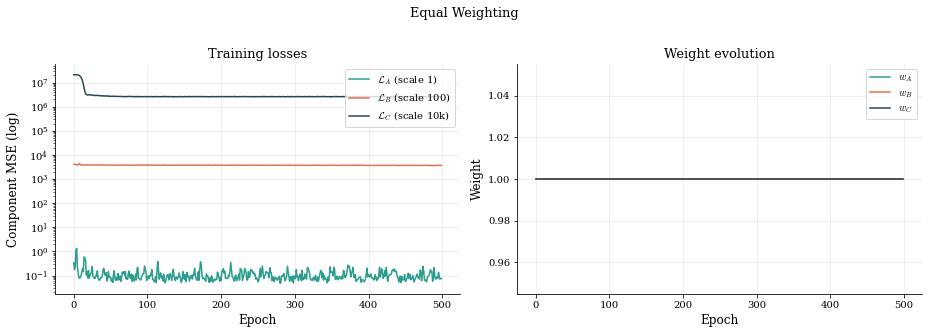

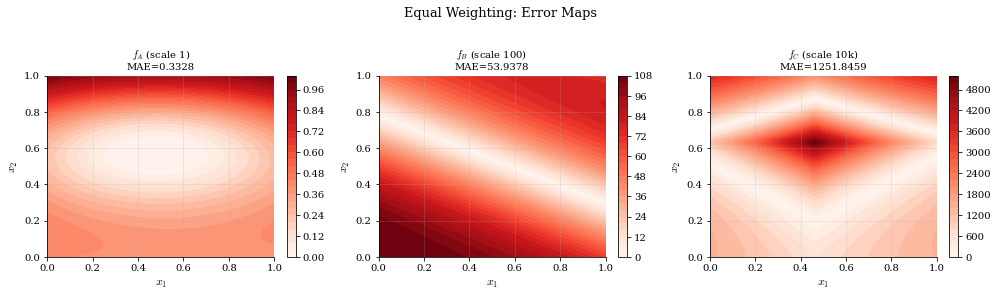

In [7]:
# ----------------------------------------------------------------
# Visualise equal-weighting results
# ----------------------------------------------------------------

def plot_training_curves(history, title, savename=None):
    """Plot per-component training losses."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Loss curves
    ax = axes[0]
    ax.semilogy(history["loss_A"], color=C_A, lw=1.5, label="$\mathcal{L}_A$ (scale 1)")
    ax.semilogy(history["loss_B"], color=C_B, lw=1.5, label="$\mathcal{L}_B$ (scale 100)")
    ax.semilogy(history["loss_C"], color=C_C, lw=1.5, label="$\mathcal{L}_C$ (scale 10k)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Component MSE (log)")
    ax.set_title("Training losses")
    ax.legend()

    # Weight evolution
    ax = axes[1]
    ax.plot(history["w_A"], color=C_A, lw=1.5, label="$w_A$")
    ax.plot(history["w_B"], color=C_B, lw=1.5, label="$w_B$")
    ax.plot(history["w_C"], color=C_C, lw=1.5, label="$w_C$")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weight")
    ax.set_title("Weight evolution")
    ax.legend()

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    if savename is not None:
        fig.savefig(f"../figures/{savename}.pdf", bbox_inches="tight")
        fig.savefig(f"../figures/{savename}.png", dpi=180, bbox_inches="tight")
    plt.show()


def plot_error_heatmaps(model, title, savename=None):
    """Plot per-function |error| heatmaps."""
    pA, pB, pC = model(tf.constant(X_grid), training=False)
    preds = [pA.numpy().flatten(), pB.numpy().flatten(), pC.numpy().flatten()]
    truths = [f_A(X_grid), f_B(X_grid), f_C(X_grid)]
    names = ["$f_A$ (scale 1)", "$f_B$ (scale 100)", "$f_C$ (scale 10k)"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, pred, truth, name in zip(axes, preds, truths, names):
        err = np.abs(truth - pred).reshape(grid_n, grid_n)
        im = ax.contourf(X1, X2, err, levels=30, cmap="Reds")
        ax.set_title(f"{name}\nMAE={err.mean():.4f}", fontsize=10)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    if savename is not None:
        fig.savefig(f"../figures/{savename}.pdf", bbox_inches="tight")
        fig.savefig(f"../figures/{savename}.png", dpi=180, bbox_inches="tight")
    plt.show()


plot_training_curves(hist_equal, "Equal Weighting", savename="loss_norm_equal_weights")
plot_error_heatmaps(model_equal, "Equal Weighting: Error Maps", savename="loss_norm_equal_errmap")


---
## 4. Inverse-Loss Weighting

$w_i^{(t)} = \frac{1}{\bar{\mathcal{L}}_i^{(t)} + \epsilon}$

with exponential averaging: $\bar{\mathcal{L}}_i^{(t)} = \beta \cdot \bar{\mathcal{L}}_i^{(t-1)} + (1-\beta) \cdot \mathcal{L}_i^{(t)}$

Training with inverse-loss weighting (500 epochs)...


Done in 18.3s
Final losses: A=6.9549e-05, B=2.2504e+03, C=2.1165e+07


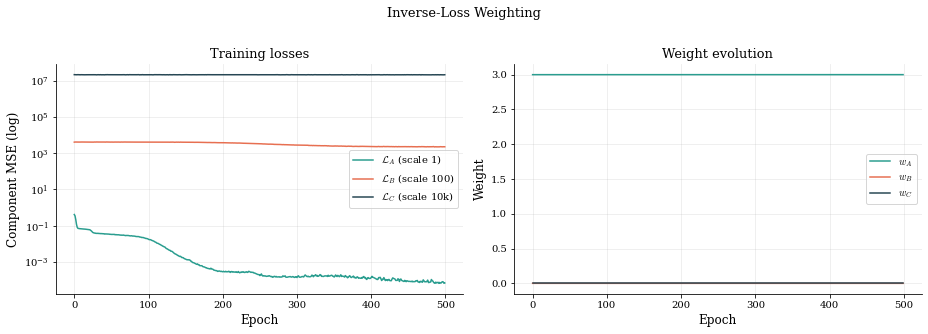

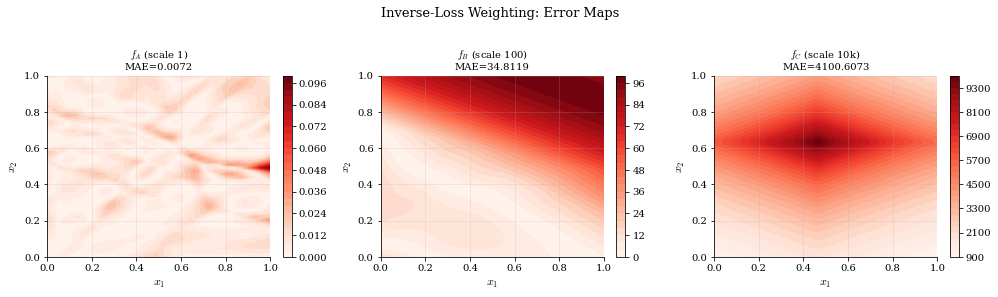

In [8]:
# ----------------------------------------------------------------
# Inverse-loss weighting
# ----------------------------------------------------------------

# We need a closure to carry the exponential average state
def make_inverse_loss_fn(beta=0.99, eps=1e-8):
    ema = [None, None, None]
    def inverse_loss_weights(losses, prev_losses, init_losses, prev_weights, epoch):
        K = len(losses)
        for i in range(K):
            if ema[i] is None:
                ema[i] = losses[i]
            else:
                ema[i] = beta * ema[i] + (1 - beta) * losses[i]
        raw = [1.0 / (ema[i] + eps) for i in range(K)]
        total = sum(raw)
        return [K * r / total for r in raw]
    return inverse_loss_weights


print(f"Training with inverse-loss weighting ({EPOCHS_BASE} epochs)...")
model_inv = build_multi_output_model()
t0 = time.time()
hist_inv = train_multi_output(
    model_inv, X_train, y_train_A, y_train_B, y_train_C,
    X_test, y_test_A, y_test_B, y_test_C,
    weight_fn=make_inverse_loss_fn(), epochs=EPOCHS_BASE
)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Final losses: A={hist_inv['loss_A'][-1]:.4e}, "
      f"B={hist_inv['loss_B'][-1]:.4e}, C={hist_inv['loss_C'][-1]:.4e}")

plot_training_curves(hist_inv, "Inverse-Loss Weighting")
plot_error_heatmaps(model_inv, "Inverse-Loss Weighting: Error Maps")


---
## 5. ReLoBRaLo: Relative Loss Balancing with Random Lookback (deterministic classroom version)

**Algorithm** (Bischof & Kraus, 2025):

At each epoch $t$:
1. **Step-wise weights:** $\hat{w}_{i,\mathrm{step}}^{(t)} = \text{softmax}_i\!\left(\frac{\mathcal{L}_i^{(t)}}{T \cdot \mathcal{L}_i^{(t-1)}}\right) \cdot K$

2. **Baseline weights:** $\hat{w}_{i,\mathrm{base}}^{(t)} = \text{softmax}_i\!\left(\frac{\mathcal{L}_i^{(t)}}{T \cdot \mathcal{L}_i^{(0)}}\right) \cdot K$

3. **Combine:** $w_i^{(t)} = \alpha\!\left[\rho \, w_i^{(t-1)} + (1-\rho)\, \hat{w}_{i,\mathrm{base}}^{(t)}\right] + (1-\alpha)\, \hat{w}_{i,\mathrm{step}}^{(t)}$

**Hyperparameters:** $T = 1.0$ (temperature), $\alpha = 0.999$ (smoothing), $\rho = 0.999$ (baseline mix in the deterministic classroom version).

In [9]:
# ----------------------------------------------------------------
# ReLoBRaLo implementation
# (adapted from Bischof & Kraus 2025, update_rules.py)
# ----------------------------------------------------------------

def make_relobralo_fn(T=1.0, alpha=0.999, rho=0.999):
    """Create a deterministic ReLoBRaLo-style weight function."""
    def relobralo_weights(losses, prev_losses, init_losses, prev_weights, epoch):
        K = len(losses)
        eps = 1e-12

        # Step-wise relative weights
        ratios = [losses[i] / (prev_losses[i] * T + eps) for i in range(K)]
        exp_ratios = np.exp(ratios - np.max(ratios))  # numerically stable softmax
        w_hat = K * exp_ratios / exp_ratios.sum()

        # Baseline (epoch-0) relative weights
        ratios0 = [losses[i] / (init_losses[i] * T + eps) for i in range(K)]
        exp_ratios0 = np.exp(ratios0 - np.max(ratios0))
        w0_hat = K * exp_ratios0 / exp_ratios0.sum()

        # Combine step-wise and baseline weights with smoothing
        new_weights = [
            rho * alpha * prev_weights[i]
            + (1 - rho) * alpha * w0_hat[i]
            + (1 - alpha) * w_hat[i]
            for i in range(K)
        ]
        return new_weights

    return relobralo_weights


print(f"Training with ReLoBRaLo (T=1.0, {EPOCHS_BASE} epochs)...")
model_relo = build_multi_output_model()
t0 = time.time()
hist_relo = train_multi_output(
    model_relo, X_train, y_train_A, y_train_B, y_train_C,
    X_test, y_test_A, y_test_B, y_test_C,
    weight_fn=make_relobralo_fn(T=1.0), epochs=EPOCHS_BASE
)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Final losses: A={hist_relo['loss_A'][-1]:.4e}, "
      f"B={hist_relo['loss_B'][-1]:.4e}, C={hist_relo['loss_C'][-1]:.4e}")


Training with ReLoBRaLo (T=1.0, 500 epochs)...


Done in 17.5s
Final losses: A=3.5200e-02, B=1.4334e+03, C=6.7153e+05


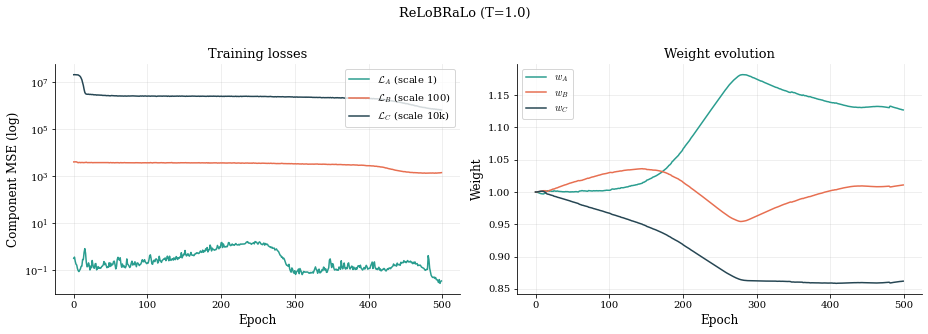

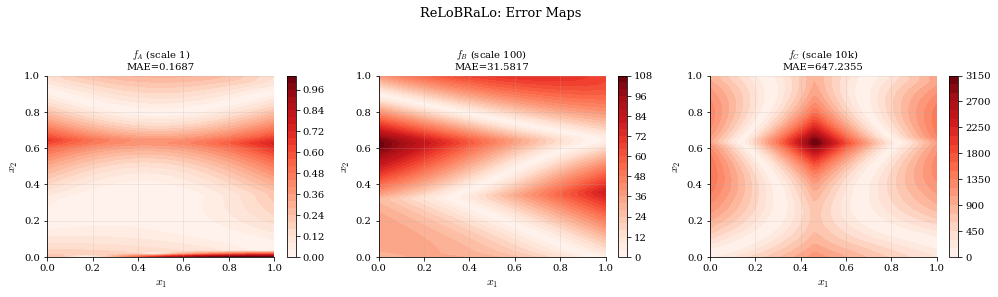

In [10]:
# ----------------------------------------------------------------
# ReLoBRaLo: weight evolution (key diagnostic plot)
# ----------------------------------------------------------------
plot_training_curves(hist_relo, "ReLoBRaLo (T=1.0)", savename="loss_norm_relobralo_weights")
plot_error_heatmaps(model_relo, "ReLoBRaLo: Error Maps", savename="loss_norm_relobralo_errmap")


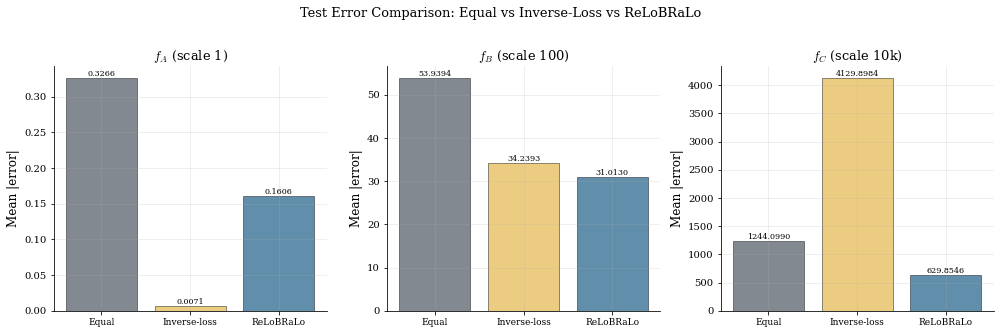

Method             f_A mean    f_B mean    f_C mean     f_A max     f_B max     f_C max
----------------------------------------------------------------------------------
Equal                0.3266     53.9394   1244.0990      1.0187    107.6122   5103.8413
Inverse-loss         0.0071     34.2393   4129.8984      0.0831     98.3490   9739.9639
ReLoBRaLo            0.1606     31.0130    629.8546      0.9705    101.7692   3101.5044


In [11]:
# ----------------------------------------------------------------
# Compare all 3 methods
# ----------------------------------------------------------------

def get_test_errors(model):
    pA, pB, pC = model(tf.constant(X_test.astype(np.float32)), training=False)
    err_A = np.abs(pA.numpy().flatten() - y_test_A)
    err_B = np.abs(pB.numpy().flatten() - y_test_B)
    err_C = np.abs(pC.numpy().flatten() - y_test_C)
    return err_A, err_B, err_C

methods = {
    "Equal":       {"model": model_equal, "color": C_EQUAL},
    "Inverse-loss": {"model": model_inv,   "color": C_INV},
    "ReLoBRaLo":   {"model": model_relo,  "color": C_RELO},
}

fn_names = ["$f_A$ (scale 1)", "$f_B$ (scale 100)", "$f_C$ (scale 10k)"]

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for fn_idx, (fn_name, ax) in enumerate(zip(fn_names, axes)):
    means = []
    maxes = []
    colors = []
    labels = []
    for mname, minfo in methods.items():
        errs = get_test_errors(minfo["model"])
        means.append(errs[fn_idx].mean())
        maxes.append(errs[fn_idx].max())
        colors.append(minfo["color"])
        labels.append(mname)

    x = np.arange(len(labels))
    bars = ax.bar(x, means, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Mean |error|")
    ax.set_title(fn_name)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Test Error Comparison: Equal vs Inverse-Loss vs ReLoBRaLo",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../figures/loss_norm_method_comparison.pdf", bbox_inches="tight")
plt.savefig("../figures/loss_norm_method_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# Summary table
print(f"{'Method':<15s}  {'f_A mean':>10s}  {'f_B mean':>10s}  {'f_C mean':>10s}  "
      f"{'f_A max':>10s}  {'f_B max':>10s}  {'f_C max':>10s}")
print("-" * 82)
for mname, minfo in methods.items():
    eA, eB, eC = get_test_errors(minfo["model"])
    print(f"{mname:<15s}  {eA.mean():10.4f}  {eB.mean():10.4f}  {eC.mean():10.4f}  "
          f"{eA.max():10.4f}  {eB.max():10.4f}  {eC.max():10.4f}")


Training ReLoBRaLo with T=0.01...


  Total relative error: 0.9764
Training ReLoBRaLo with T=0.1...


  Total relative error: 0.8444
Training ReLoBRaLo with T=1.0...


  Total relative error: 0.8872
Training ReLoBRaLo with T=10.0...


  Total relative error: 0.9569


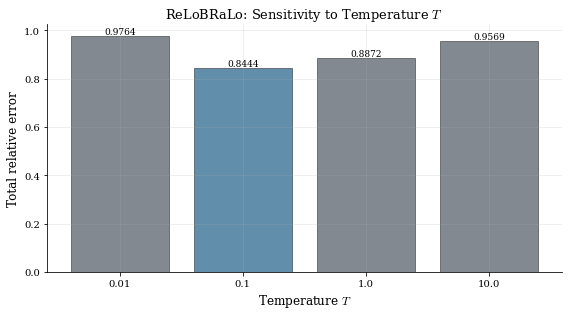


T       Rel. error     f_A MAE     f_B MAE     f_C MAE
----------------------------------------------------
0.01        0.9764      0.3148     53.7564   1240.4087
0.10        0.8444      0.1825     53.7560   1243.6167
1.00        0.8872      0.2174     54.5440   1243.8212
10.00       0.9569      0.2944     53.8152   1243.0726


In [12]:
# ----------------------------------------------------------------
# Sensitivity: sweep T in {0.01, 0.1, 1.0, 10.0}
# ----------------------------------------------------------------
T_values = T_VALUES_SWEEP
sensitivity_results = {}

for T_val in T_values:
    print(f"Training ReLoBRaLo with T={T_val}...")
    model_t = build_multi_output_model()
    hist_t = train_multi_output(
        model_t, X_train, y_train_A, y_train_B, y_train_C,
        X_test, y_test_A, y_test_B, y_test_C,
        weight_fn=make_relobralo_fn(T=T_val), epochs=EPOCHS_BASE
    )
    eA, eB, eC = get_test_errors(model_t)
    # Normalised total error (relative to function scale)
    total_rel_err = eA.mean() / 1.0 + eB.mean() / 100.0 + eC.mean() / 10000.0
    sensitivity_results[T_val] = {
        "total_rel_err": total_rel_err,
        "err_A": eA.mean(), "err_B": eB.mean(), "err_C": eC.mean()
    }
    print(f"  Total relative error: {total_rel_err:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4.5))
T_labels = [str(T) for T in T_values]
total_errs = [sensitivity_results[T]["total_rel_err"] for T in T_values]
bar_colors = [C_RELO if err == min(total_errs) else C_EQUAL for err in total_errs]

bars = ax.bar(T_labels, total_errs, color=bar_colors, alpha=0.85,
              edgecolor="black", linewidth=0.5)
ax.set_xlabel("Temperature $T$")
ax.set_ylabel("Total relative error")
ax.set_title("ReLoBRaLo: Sensitivity to Temperature $T$")
for bar, val in zip(bars, total_errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.savefig("../figures/loss_norm_T_sensitivity.pdf", bbox_inches="tight")
plt.savefig("../figures/loss_norm_T_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\n{'T':<6s}  {'Rel. error':>10s}  {'f_A MAE':>10s}  {'f_B MAE':>10s}  {'f_C MAE':>10s}")
print("-" * 52)
for T in T_values:
    r = sensitivity_results[T]
    print(f"{T:<6.2f}  {r['total_rel_err']:10.4f}  {r['err_A']:10.4f}  "
          f"{r['err_B']:10.4f}  {r['err_C']:10.4f}")


---
## 8. Discussion

### Key observations

1. **Equal weighting fails** when loss components differ by more than
   $\sim 10\times$ in scale. The large-scale component dominates the
   gradient, and the small-scale component is essentially ignored.

2. **Inverse-loss weighting** provides a simple fix but can be unstable,
   especially when losses approach zero.

3. **ReLoBRaLo** (Relative Loss Balancing with Random Lookback) provides
   robust, adaptive balancing by using *relative* loss changes and a
   deterministic baseline/history blend that prevents weight drift in this
   notebook version.

4. The **temperature** $T$ controls the sharpness of the rebalancing:
   - $T \ll 1$: winner-take-all (only one component trained at a time)
   - $T \gg 1$: near-equal weights (reverts to the scale problem)
   - $T \approx 1$: robust default that works well in most cases

### When to use loss balancing in economics

- **PINNs:** PDE residual + boundary + initial conditions at different scales
- **DSGE / DEQNs:** Euler equations, budget constraints, and market clearing
  conditions often have different units and magnitudes
- **Multi-task learning:** Predicting multiple economic variables from
  shared features (e.g., GDP, inflation, unemployment)

### References

- Bischof & Kraus (2025). *Multi-objective loss
  balancing for physics-informed deep learning.* arXiv:2110.09813; published in Computer Methods in Applied Mechanics and Engineering 439:117914, 2025.
- Chen, Badrinarayanan, Lee & Rabinovich (2018). *GradNorm: Gradient
  normalization for adaptive loss balancing in deep multitask networks.* ICML.
- Heydari, Thompson & Mehmood (2019). *SoftAdapt: Techniques for adaptive
  loss weighting of neural networks with multi-part loss functions.*
  arXiv:1912.12355.